# Create a DataFrame Object Using read_csv

In the previous pages, we created a DataFrame object by setting up a disctionary where each pair of key-values specifies ONE COLUMN of the DataFrame. The process is tedious and will become very cumbersome when we want to work with large amount of data. Fortunately, large data sets are commonly stored and shared digitally in a format called  [Comma Separated Values (CSV)](https://en.wikipedia.org/wiki/Comma-separated_values). Typically, the first line of a CSV file contains the headings for the columns.

The `pandas` library supports a function called [`read_csv`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) that can create `DataFrame` objects by loading data from CSV files. The only **required argument** for the `read_csv` function is a string indicating where the CSV file is stored, as shown by **line 2 of the following code block**. The assignment operator saves the `DataFrame` object created by the `read_csv` function into a variable called `df`, a common name developers use when they are working on only one DataFrame object.  

The rest of this page depends on the successful loading of the CSV data into df. Therefore, whenever you open or reconnect to this page, it is important to always **run this code block first** before working on the other code blocks of the page.

In [ ]:
import pandas as pd
# set float display format to comma as thousand separator and 2 digits after the decimal point
pd.options.display.float_format = '{:,.2f}'.format

df = pd.read_csv('https://raw.githubusercontent.com/qarnac/cs201/refs/heads/main/insured_by_states_18_64.csv')

# I created this dataset using HDPulse data under Healthcare System -> Insurance
# The data shows how many people aged 18 - 64 were insured in 2023
# It is critical to run this block first before running any of the following code blocks. Otherwise, data will not be ready in df.

## Initial inspection practice

When getting a new dataset, it is important to perform common initial inspection to gain a better understanding of the data.

In [ ]:
# Use an appropriate attribute to show the number of rows and columns in the dataset
df.shape

(51, 13)

In [ ]:
# Use the columns attribute to show the names of columns
df.columns

Index(['State', 'All_Percent', 'All_People', 'White_Percent', 'White_People',
       'Black_Percent', 'Black_People', 'AI_AN_Percent', 'AI_AN_People',
       'API_Percent', 'API_People', 'Hispanic_Percent', 'Hispanic_People'],
      dtype='object')

In [ ]:
# Call the info function on our DataFrame object.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             51 non-null     object 
 1   All_Percent       51 non-null     float64
 2   All_People        51 non-null     int64  
 3   White_Percent     51 non-null     float64
 4   White_People      51 non-null     int64  
 5   Black_Percent     51 non-null     float64
 6   Black_People      51 non-null     int64  
 7   AI_AN_Percent     51 non-null     float64
 8   AI_AN_People      51 non-null     int64  
 9   API_Percent       51 non-null     float64
 10  API_People        51 non-null     int64  
 11  Hispanic_Percent  51 non-null     float64
 12  Hispanic_People   51 non-null     int64  
dtypes: float64(6), int64(6), object(1)
memory usage: 5.3+ KB


**Add a text block** to write down what you think about the data by answering the following questions in a text block.

*  How many rows are there?
*  How many columns are there?
*  There are several pairs of the xx_Percent and xx_People columns. What do you think they are? How are they related to or different from each other?

In [ ]:
# Call the head function to show the first 10 states


In [ ]:
# Call an appropriate function to show descriptive statistics for the dataset


**Add a text block** to write down what you think about the data by answering the following questions in a text block.

*  What is the average percent of insured for all people 18 - 64 among all states?
*  What is the average percent of insured for a race of your choice among all states?
*  What is the lowest percent of insured for a race of your choice among all states?
*  What is the lowest number of insured for a race of your choice among all states?
*  Which race has more/less variation of insured percent when compared to others?
*  Why do the above questions focus on percentage of insured instead of the number of people insured?

# Data Wrangling

The result of the describe function tells us the lowest, highest, and the four quantiles of each column. However, it does not tell us which states hold these respective values.

**Data wrangling** is the process used by data scientists to get the data ready to be analyzed and interpreted. It helps social scientists to answer questions about social patterns, inequalities, and relationships between groups.

Before starting the data wrangling process, it's important to think about the questions we want to ask. Here are a few examples:

*  Does racial inequality in health insurance coverage vary accross states?
*  Which states have the largest racial gaps in insurance coverage?
*  Is the size of racial insurance gaps geographically patterned?

## Select columns

The original dataset contains both the percentage of insured and the number of people insured. Larger states are likely to have more people insured even though their percentage of insured may not be so great.

The following code block helps us to focus on columns with percentage data. The `copy` function helps make sure that we are working on a copy of the original dataset and that any potential change we make to the new dataset will not affect the original.

In [ ]:
# Create a new DataFrame object to hold only the columns for percentage of insured
percent_columns = ['State', 'All_Percent', 'White_Percent', 'Black_Percent', 'AI_AN_Percent', 'API_Percent', 'Hispanic_Percent']
percent_df = df[percent_columns].copy()
percent_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             51 non-null     object 
 1   All_Percent       51 non-null     float64
 2   White_Percent     51 non-null     float64
 3   Black_Percent     51 non-null     float64
 4   AI_AN_Percent     51 non-null     float64
 5   API_Percent       51 non-null     float64
 6   Hispanic_Percent  51 non-null     float64
dtypes: float64(6), object(1)
memory usage: 2.9+ KB


### Practice

In [ ]:
# Create a new DataFrame object to contain a different set of columns of your choice.
# It is important to call the copy function.
# Please use descriptive name for your new dataset.

## Rename columns

Now that our dataset contains only the percentage data, having _percent as part of the column names become redundant. The following code block shows how we can rename any column of a DataFrame object.

*  It uses a dictionary structure to create a mapping between the old and new column names.
*  The `rename` function is then call to apply the mapping using the `columns` parameter.
*  The recommended practice is to save the result of the `rename` function back to the DataFrame object instead of using `inplace=True` inside the rename function. Using `inplace=True` works best when the dataset is extremely large.

In [ ]:
map = {'All_Percent': 'All_Races', 'White_Percent': 'White'}
percent_df = percent_df.rename(columns=map)
percent_df.columns

Index(['State', 'All_Races', 'White', 'Black_Percent', 'AI_AN_Percent',
       'API_Percent', 'Hispanic_Percent'],
      dtype='object')

### Practice

In [ ]:
# Rename the rest of the columns in the DataFrame to remove _percent


## Create new columns

Last time, we use the `rank` function to help assign ranks for rows based a numeric column. The following code block provides an example to rank the states based on their insurance coverage for all races.

*  The `rank` function does not change any value in `percent_df['All_Races']`.
*  It does not rearrange the rows of the DataFrame object.
*  It simply creates a new `Series` that can be assigned to a new column of the DataFrame object.
*  `ascending=False` indicates that the highest value will get first rank. If we want the lowest value to get the first rank, we should set `ascending=True`.
*  `method='dense'` indicates that there will be no gaps in ranks and ties share a rank. If we want tied values to get the best (lowest) rank and the next rank skips, we will need to use `method='min'`

In [ ]:
percent_df['Overall_rank'] = percent_df['All_Races'].rank(ascending=False, method='dense')
percent_df.head()

,State,All_Races,White,Black_Percent,AI_AN_Percent,API_Percent,Hispanic_Percent,Overall_rank
0,Alabama,87.30,90.10,85.30,83.30,89.90,64.40,31.00
1,Alaska,85.30,89.50,81.80,72.60,85.80,73.30,38.00
2,Arizona,86.20,91.80,87.40,75.40,92.40,77.30,35.00
3,Arkansas,87.70,90.50,87.10,82.50,90.20,68.00,30.00
4,California,91.00,95.40,92.90,87.20,95.20,85.30,20.00


We also used the `cut` function to create a new column that classifies a numeric column into groups. The following code block shows an example of classifying the overall insurance coverage based on their quantiles. As a reminder:

*  The first parameter is the numeric column for which we want to classify. In this case, we used the 'Overall' columns.
*  The `bins` parameter specifies the ranges that will be used to break down the numeric values. By default, the ranges are lower/left exclusive and upper/right inclusive.  
*  The `labels` parameter specifies the labels for respective ranges.

In [ ]:
# This will mark values > 78.40 to 87.15 as first 25%, >87.15 to 91 as second 25%,
# > 91 to 92.65 as third 25%, > 92.65 to 96.50 as last 25%
# Right/upper inclusive means 87.15 belongs to the first bin
# Left/lower exclusive means 87.15 does not belong to the second bin
overall_bins = [78.40, 87.15, 91, 92.65, 96.50]
overall_labels = ['lowest 25%', 'second 25%', 'third 25%', 'hightest 25%']
percent_df['Overall_Qauntiles'] = pd.cut(percent_df['All_Races'],
                                   bins = overall_bins,
                                   labels = overall_labels)
percent_df.head()

,State,All_Races,White,Black_Percent,AI_AN_Percent,API_Percent,Hispanic_Percent,Overall_rank,Overall_Qauntiles
0,Alabama,87.30,90.10,85.30,83.30,89.90,64.40,31.00,second 25%
1,Alaska,85.30,89.50,81.80,72.60,85.80,73.30,38.00,first 25%
2,Arizona,86.20,91.80,87.40,75.40,92.40,77.30,35.00,first 25%
3,Arkansas,87.70,90.50,87.10,82.50,90.20,68.00,30.00,second 25%
4,California,91.00,95.40,92.90,87.20,95.20,85.30,20.00,second 25%


We can also create a new column by performing arithmetic operations between two numeric columns. For example, the following code block shows how to create a new column to hold the disparity between White and overall insurance coverage.

In [ ]:
percent_df['White_diff'] = percent_df['White'] - percent_df['All_Races']
percent_df.head()

,State,All_Races,White,Black_Percent,AI_AN_Percent,API_Percent,Hispanic_Percent,Overall_rank,Overall_Qauntiles,White_diff
0,Alabama,87.30,90.10,85.30,83.30,89.90,64.40,31.00,second 25%,2.80
1,Alaska,85.30,89.50,81.80,72.60,85.80,73.30,38.00,first 25%,4.20
2,Arizona,86.20,91.80,87.40,75.40,92.40,77.30,35.00,first 25%,5.60
3,Arkansas,87.70,90.50,87.10,82.50,90.20,68.00,30.00,second 25%,2.80
4,California,91.00,95.40,92.90,87.20,95.20,85.30,20.00,second 25%,4.40


### Practice

In [ ]:
# Add a rank column for a race of your choice


# Add a classification column for a race of your choice


# Add a new column to show insurance coverage disparity of your choice


# Show the first few rows of the updated dataset
percent_df.head()

,State,All_Races,White,Black_Percent,AI_AN_Percent,API_Percent,Hispanic_Percent,Overall_rank,Overall_Qauntiles,White_diff
0,Alabama,87.30,90.10,85.30,83.30,89.90,64.40,31.00,second 25%,2.80
1,Alaska,85.30,89.50,81.80,72.60,85.80,73.30,38.00,first 25%,4.20
2,Arizona,86.20,91.80,87.40,75.40,92.40,77.30,35.00,first 25%,5.60
3,Arkansas,87.70,90.50,87.10,82.50,90.20,68.00,30.00,second 25%,2.80
4,California,91.00,95.40,92.90,87.20,95.20,85.30,20.00,second 25%,4.40


# The matplotlib Library

Descriptive statistics are helpful to provide a high level overview of the data. Data scientists often use **data visualization** to gain additional insights about the data.

The [matplotlib library](https://matplotlib.org/) supports functions for creating static, animated, and interative visualizations. It is a third-party library. Fortunately, Google Colab already includes this library in its environment. If you are running Python in an environment that does not already support this library, you will need to run the following to install it.

In [ ]:
!pip install matplotlib
#Do not run this block since Google Colab already supports both numpy and matplotlib

The `matplotlib` is a huge library that include several sub-libraries/modules in it. The main module we will be using from `matplotlib` is `pyplot`. It is important and a common practice for developers to include the following `import` statement before plotting their graphs. This statement also helps developers to use `plt` as the abbreviation of `pyplot` when calling functions from the `pyplot` library.

In [ ]:
import matplotlib.pyplot as plt

When we create visualizations in Python using matplotlib, we often start by setting up the basic structure of the graph using several key plt functions.

*  The plt.figure() function opens a new “canvas” where the plot will appear and allows you to control the size or layout of the graph.
*  The plt.title() adds a descriptive title that helps the viewer understand what the graph shows.
*  The plt.xlabel() and plt.ylabel() functions label the axes, giving meaning to the horizontal and vertical dimensions of the graph
*  The plt.tight_layout() function automatically adjusts spacing to avoid overlap.
*  The plt.grid() function decides whether to show a grid in the background of the graph.
*  The plt.show() displays the completed graph.

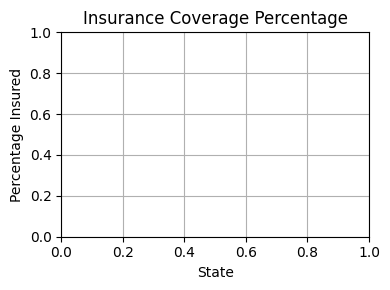

In [ ]:
# visualization
import matplotlib.pyplot as plt     # import appropriate library

plt.figure(figsize=(4, 3))          # set the size of the chart
plt.grid()                          # show grid to in the background
plt.title('Insurance Coverage Percentage')   # set the title for the chart
plt.xlabel('State')                 # set the label for the x-axis
plt.ylabel('Percentage Insured')    # set the label for the y-axis

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the grath

The plt.xticks() and plt.yticks() functions control how labels appear along the axes.

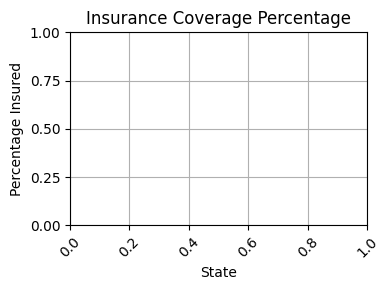

In [ ]:
# visualization
import matplotlib.pyplot as plt     # import appropriate library

plt.figure(figsize=(4, 3))          # set the size of the chart
plt.grid()                          # show grid to in the background
plt.title('Insurance Coverage Percentage')   # set the title for the chart
plt.xlabel('State')                 # set the label for the x-axis
plt.ylabel('Percentage Insured')    # set the label for the y-axis
plt.xticks(rotation=45)             # rotate the labels on the x-axis by 45 degree
plt.yticks([0, 0.25, 0.5, 0.75, 1.0]) # specify the tick spacing on the y-axis

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()

## Practice

In [ ]:
# Set up a different structure using the above functions


# Bar charts

Bar charts are one of the most common and effective ways to visualize data. They are intuitive and easy to read.

In a bar chart:
- Each **bar** represents a category.
- The **height** of the bar shows the value associated with that category.
- Bars can be grouped or stacked to show comparisons across multiple variables.

Before generating bar charts, the following code block use row filtering to create a DataFrame with data from our four neighboring states.


In [ ]:
# data preparation
selected_states = ['Arizona', 'California', 'Nevada', 'Oregon']
condition = percent_df['State'].isin(selected_states)
chart_df = percent_df[condition].copy()

The pandas' `plot` function is built on top of `matplotlib` and supports many parameters to specify details of a graph generated by matplotlit.

For example, the following code block shows how to use the plot function to set up a bar chart:

*  The `kind` parameter is set to `'bar'`, indicating a **bar chart** is to be created.
*  The `x` parameter indicates the column from which the values for the **x-axis** will be drawn. It is set to the `'State'` column.
*  The `y` parameter indicates the column from which the values for the y-axis will be drawn. It is set to the `'All_Races'` column.
*  The `figsize` parameter helps set the figure size as in `plt.figure` function.


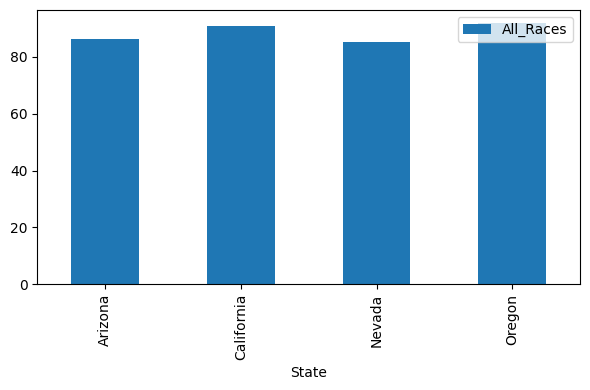

In [ ]:
import matplotlib.pyplot as plt     # import appropriate library

# create the bar chart before adjusting title and others
chart_df.plot(kind='bar', x='State', y='All_Races', figsize=(6, 4))

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart

The above bar chart helps visualize a few things:

*  All four states have higher than 80% insurance coverage.
* Oregon has the highest coverage among the four states.
*  Nevada has the lowest coverage among the four states.

There are additional parameters we can specify for the `plot` function.

*  The title parameter specifies the title for the graph.
*  The xlabel and ylabels parameters specify the labels to be put on the respective axis.
*  The rot parameter specifies rotation of x-tick labels.

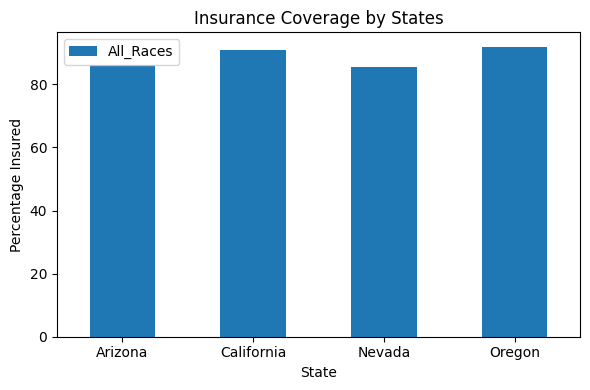

In [ ]:
import matplotlib.pyplot as plt     # import appropriate library

# create the bar chart
chart_df.plot(kind='bar',       # to create a bar chart
              x='State',        # the column whose values will be used for the x-axis
              y='All_Races',    # the column whose values will be used for the y-axis
              figsize=(6, 4),   # 600 pixels for the width, 400 pixels for the height
              title='Insurance Coverage by States',     # title of the graph
              ylabel='Percentage Insured',              # label for the y-axis
              rot=0             # Rotation of the x-ticks values
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart


The plot function also allows the y parameter to include multiple columns as shown in the following code block.

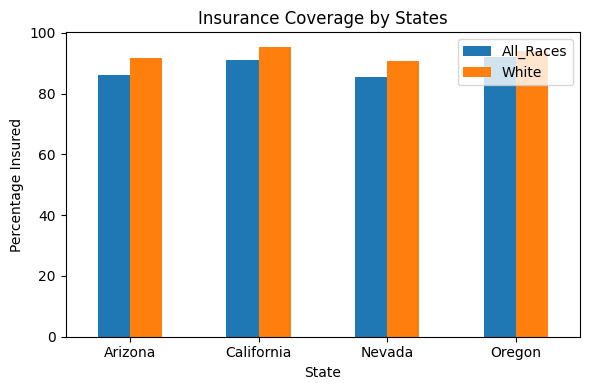

In [ ]:
import matplotlib.pyplot as plt     # import appropriate library

# create the bar chart
chart_df.plot(kind='bar', x='State', y=['All_Races', 'White'], figsize=(6, 4),
              title='Insurance Coverage by States',
              ylabel='Percentage Insured',
              rot=0
)

plt.tight_layout()                  # adjust spacing to avoid overlap
plt.show()                          # show the chart


The above bar chart helps visualize a few things:

*  In all four states, insurance coverage for white is better than the overall insurance coverage.
*  The gaps is the smallest in Oregon.

### Practice

In [ ]:
# Data preparation: Create a new DataFrame object from percent_df using a filtering condition of your choice


In [ ]:
# Create a bar chart to compare insurance coverage for one column of your choice among the states in your new dataset.


In [ ]:
# Create a bar chart to compare insurance converage for multiple columns of your choice among the states in your new dataset.


**Add a text block** to communicate key observations from the above bar charts.